# Plotting Tools

In [2]:
import os
import csv

import numpy as np
from scipy.io import loadmat, savemat
import matplotlib.pyplot as plt

### Basic plotting example

In [3]:
## full ancestors
returns_full = [
    loadmat("./scripts/log/2026-04-21--17:35:58/logs.mat")["returns"],
    loadmat("./scripts/log/2026-04-21--17:36:02/logs.mat")["returns"],
    loadmat("./scripts/log/2026-04-21--20:26:52/logs.mat")["returns"]
]

## pruned ancestors
returns_graph_1 = [
    loadmat("./scripts/log/2026-04-21--09:25:47/logs.mat")["returns"],
    loadmat("./scripts/log/2026-04-21--16:03:12/logs.mat")["returns"],
    loadmat("./scripts/log/2026-04-21--16:03:14/logs.mat")["returns"]
]

returns_graph_2 = [
    loadmat("./scripts/log/2026-04-20--23:01:29/logs.mat")["returns"],
    loadmat("./scripts/log/2026-04-20--23:01:33/logs.mat")["returns"],
    loadmat("./scripts/log/2026-04-21--09:25:26/logs.mat")["returns"]
]

returns_graph_3 = [
    loadmat("./scripts/log/2026-04-20--10:59:59/logs.mat")["returns"],
    loadmat("./scripts/log/2026-04-20--11:00:04/logs.mat")["returns"],
    loadmat("./scripts/log/2026-04-20--01:06:20/logs.mat")["returns"]
]

returns_graph_4 = [
    loadmat("./scripts/log/2026-04-20--09:16:53/logs.mat")["returns"],
    loadmat("./scripts/log/2026-04-20--09:17:40/logs.mat")["returns"],
    loadmat("./scripts/log/2026-04-20--14:44:06/logs.mat")["returns"]
]

returns_graph_5 = [
    loadmat("./scripts/log/2026-04-20--14:44:58/logs.mat")["returns"],
    loadmat("./scripts/log/2026-04-20--16:17:28/logs.mat")["returns"],
    loadmat("./scripts/log/2026-04-20--16:17:35/logs.mat")["returns"]
]

In [4]:
returns_full = np.array(returns_full).reshape([3, -1])
returns_graph_1 = np.array(returns_graph_1).reshape([3, -1])
returns_graph_2 = np.array(returns_graph_2).reshape([3, -1])
returns_graph_3 = np.array(returns_graph_3).reshape([3, -1])
returns_graph_4 = np.array(returns_graph_4).reshape([3, -1])
returns_graph_5 = np.array(returns_graph_5).reshape([3, -1])

In [5]:
returns_full = np.maximum.accumulate(returns_full, axis=-1)
returns_graph_1 = np.maximum.accumulate(returns_graph_1, axis=-1)
returns_graph_2 = np.maximum.accumulate(returns_graph_2, axis=-1)
returns_graph_3 = np.maximum.accumulate(returns_graph_3, axis=-1)
returns_graph_4 = np.maximum.accumulate(returns_graph_4, axis=-1)
returns_graph_5 = np.maximum.accumulate(returns_graph_5, axis=-1)

In [6]:
returns_full = np.mean(returns_full, axis=0)
returns_graph_1 = np.mean(returns_graph_1, axis=0)
returns_graph_2 = np.mean(returns_graph_2, axis=0)
returns_graph_3 = np.mean(returns_graph_3, axis=0)
returns_graph_4 = np.mean(returns_graph_4, axis=0)
returns_graph_5 = np.mean(returns_graph_5, axis=0)

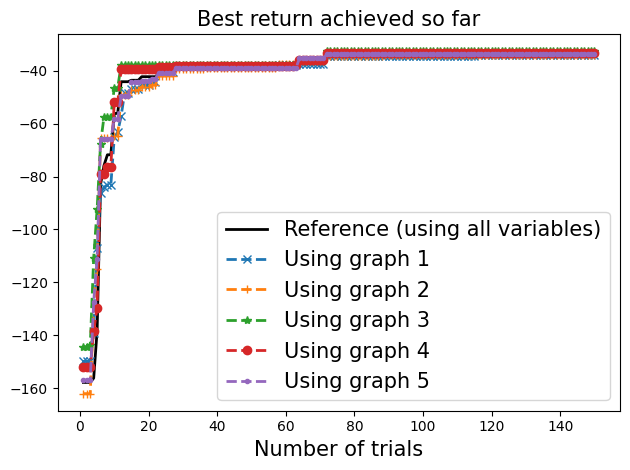

In [7]:
min_num_trials = 150
# Plot result
plt.figure()
plt.plot(np.arange(1, min_num_trials + 1), returns_full, "k-", linewidth=2)
plt.plot(np.arange(1, min_num_trials + 1), returns_graph_1, "--x", linewidth=2)
plt.plot(np.arange(1, min_num_trials + 1), returns_graph_2, "--+", linewidth=2)
plt.plot(np.arange(1, min_num_trials + 1), returns_graph_3, "--*", linewidth=2)
plt.plot(np.arange(1, min_num_trials + 1), returns_graph_4, "--o", linewidth=2)
plt.plot(np.arange(1, min_num_trials + 1), returns_graph_5, "--.", linewidth=2)
plt.legend(
    [
        "Reference (using all variables)", 
        "Using graph 1",
        "Using graph 2",
        "Using graph 3",
        "Using graph 4",
        "Using graph 5",
    ],
    fontsize=15,
)
# plt.title("Performance", fontsize=15)
plt.xlabel("Number of trials", fontsize=15)
plt.title("Best return achieved so far", fontsize=15)
plt.tight_layout()
plt.savefig("./results.png", dpi=200)
plt.show()

In [8]:
returns_full.shape

(150,)

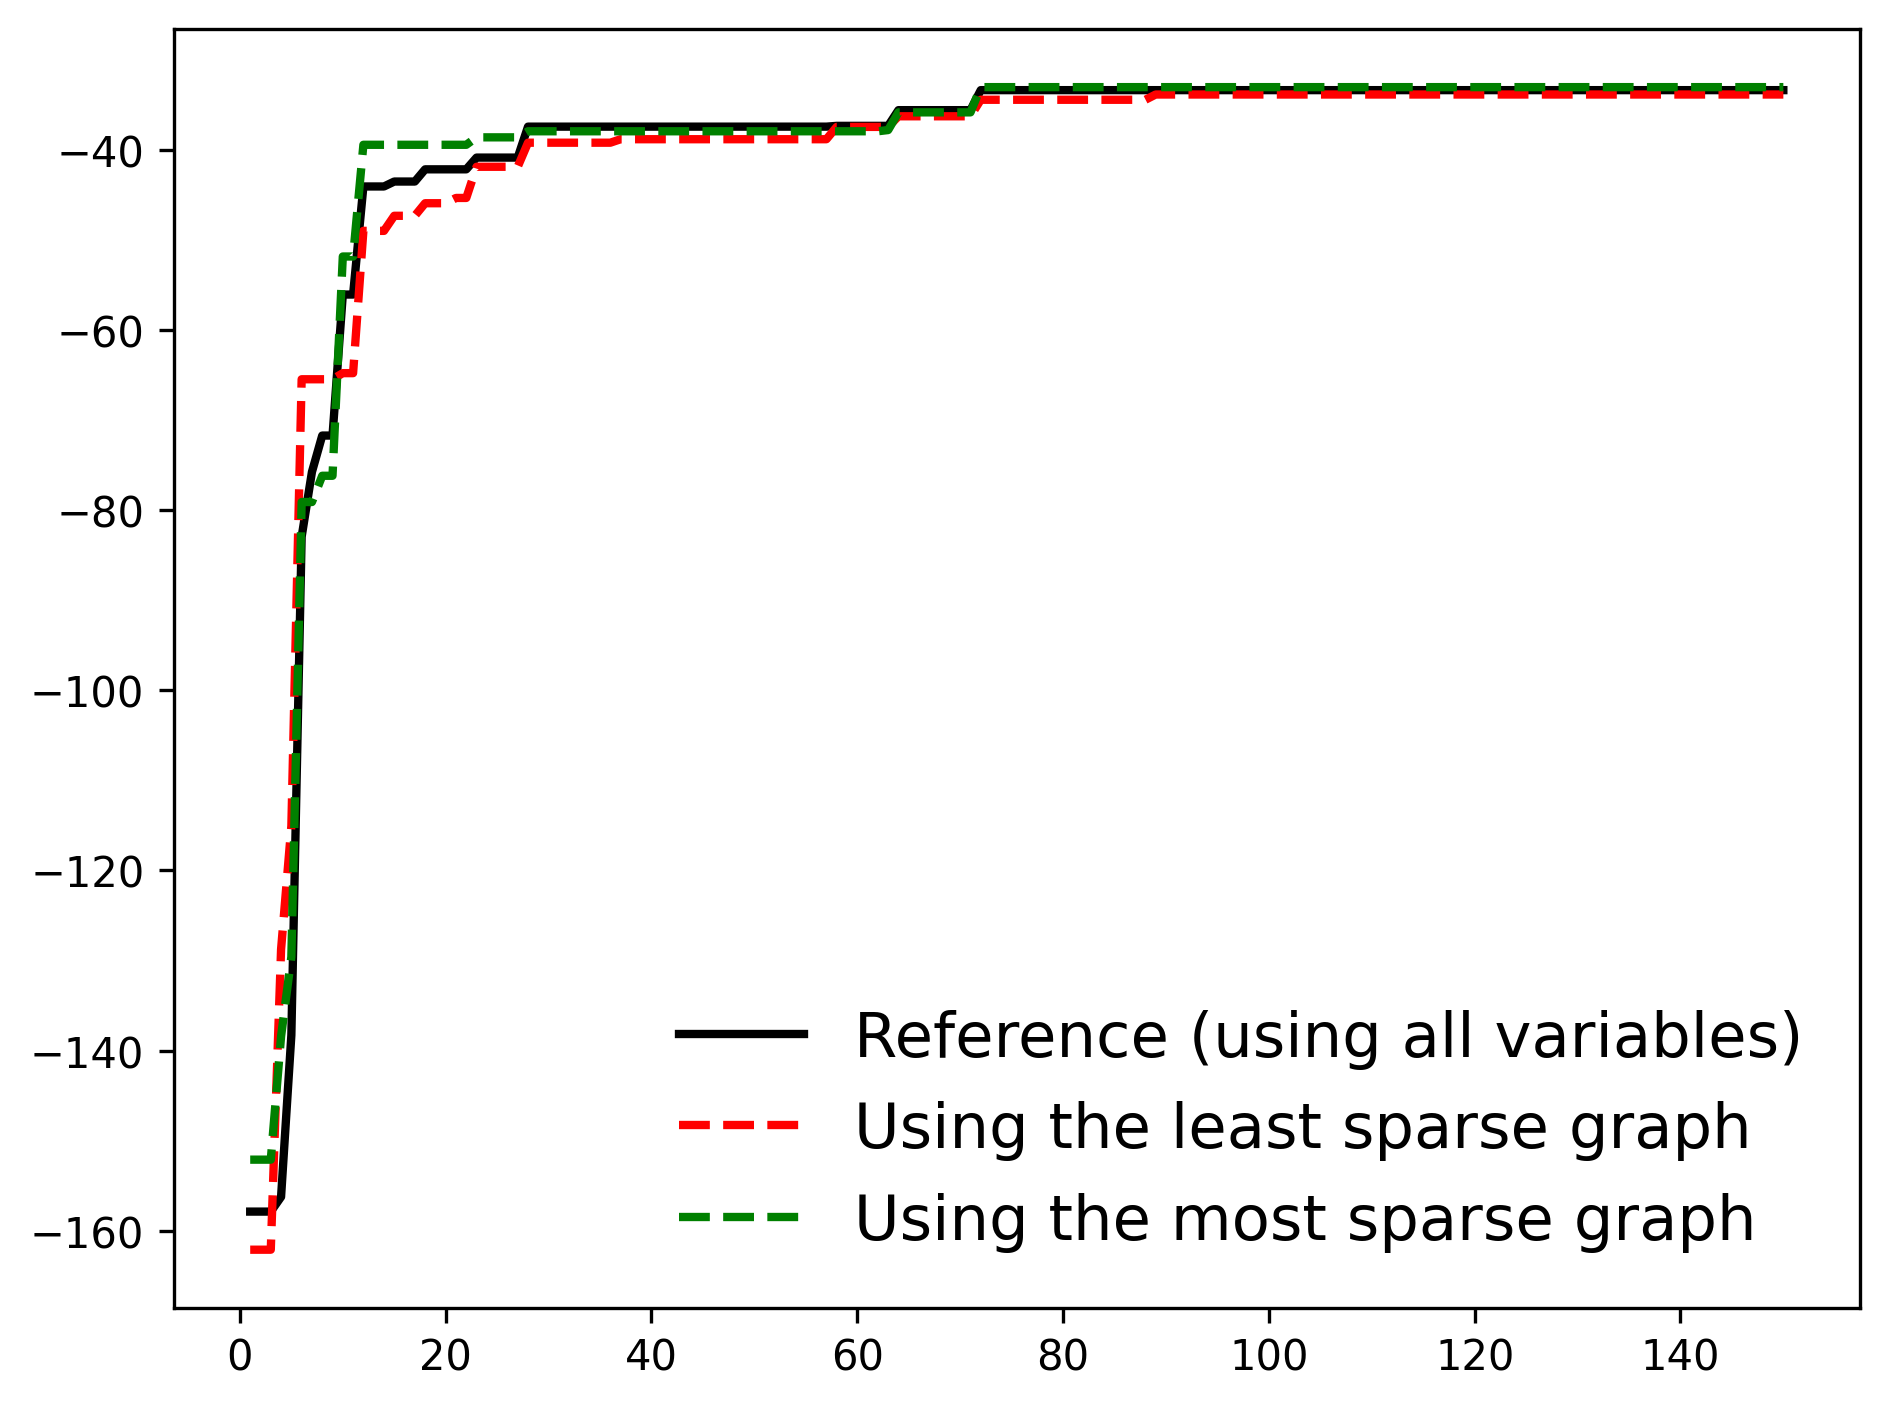

In [12]:
min_num_trials = 150
# Plot result
plt.figure(dpi=300)
plt.plot(np.arange(1, min_num_trials + 1), returns_full, "k-", linewidth=2)
# plt.plot(np.arange(1, min_num_trials + 1), returns_graph_1, "--x", linewidth=2)
plt.plot(np.arange(1, min_num_trials + 1), returns_graph_2, "r--", linewidth=2)
# plt.plot(np.arange(1, min_num_trials + 1), returns_graph_3, "--*", linewidth=2)
plt.plot(np.arange(1, min_num_trials + 1), returns_graph_4, "g--", linewidth=2)
# plt.plot(np.arange(1, min_num_trials + 1), returns_graph_5, "--.", linewidth=2)
plt.legend(
    [
        "Reference (using all variables)", 
        "Using the least sparse graph",
        "Using the most sparse graph",
    ],
    fontsize=15,
    frameon=False,
)
# plt.title("Performance", fontsize=15)
# plt.xlabel("Number of trials", fontsize=15)
# plt.title("Best return achieved so far", fontsize=15)
plt.tight_layout()
plt.savefig("./results.png", dpi=300)
plt.show()